# EchoROI: Training Results and Model Evaluation

This notebook reviews the training results of the **unified EchoROI U-Net model** trained on
1,206 echocardiogram images from three datasets:

| Dataset | Source | Samples |
|---|---|---|
| MIMIC-IV-ECHO | PhysioNet | ~800 |
| EchoNet-Dynamic | Stanford | ~145 |
| EchoNet-Paediatric | EchoNet | ~263 |

**Architecture:** U-Net (4 encoder + 4 decoder blocks, 31M parameters)  
**Task:** Binary segmentation of echocardiographic ROI sector  
**Input:** 256×256 grayscale | **Output:** 256×256 binary mask

---

## 1. Training Summary

Load the training artifacts generated during model training.

In [1]:
import json
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Navigate to project root
os.chdir(Path("__file__").resolve().parent.parent if "__file__" in dir() else Path.cwd().parent)
print(f"Working directory: {os.getcwd()}")

# Load training artifacts
with open("training_results/dataset_summary.json") as f:
    summary = json.load(f)

with open("training_results/metrics.json") as f:
    metrics = json.load(f)

with open("training_results/training_log.csv") as f:
    log = list(csv.DictReader(f))

print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total samples:      {summary['total_samples']}")
print(f"Training samples:   {summary['training_samples']}")
print(f"Validation samples: {summary['validation_samples']}")
print(f"Image size:         {summary['image_size']}")
print(f"Epochs completed:   {summary['epochs_completed']} / {summary['epochs_configured']}")
print(f"Batch size:         {summary['batch_size']}")
print(f"Learning rate:      {summary['learning_rate']}")
print()
print("BEST VALIDATION METRICS")
print("-" * 40)
print(f"Val Loss:        {summary['best_val_loss']:.4f}")
print(f"Val Dice:        {summary['best_val_dice']:.4f}")
print(f"Val IoU:         {summary['best_val_iou']:.4f}")
print()
print("FINAL VALIDATION METRICS (on best model)")
print("-" * 40)
for k, v in metrics.items():
    if k not in ('intersection', 'union'):
        print(f"  {k:20s}: {v:.4f}")

Working directory: /Volumes/G-DRIVE PRO/UNET-Ultrasound-ROI-Segmentation
TRAINING SUMMARY
Total samples:      1206
Training samples:   964
Validation samples: 242
Image size:         [256, 256]
Epochs completed:   29 / 50
Batch size:         8
Learning rate:      0.0001

BEST VALIDATION METRICS
----------------------------------------
Val Loss:        0.0266
Val Dice:        0.9855
Val IoU:         0.9715

FINAL VALIDATION METRICS (on best model)
----------------------------------------
  dice                : 0.9872
  iou                 : 0.9747
  accuracy            : 0.9900
  sensitivity         : 0.9857
  specificity         : 0.9928


## 2. Training Curves

Visualize loss, accuracy, Dice coefficient, and IoU over training epochs.

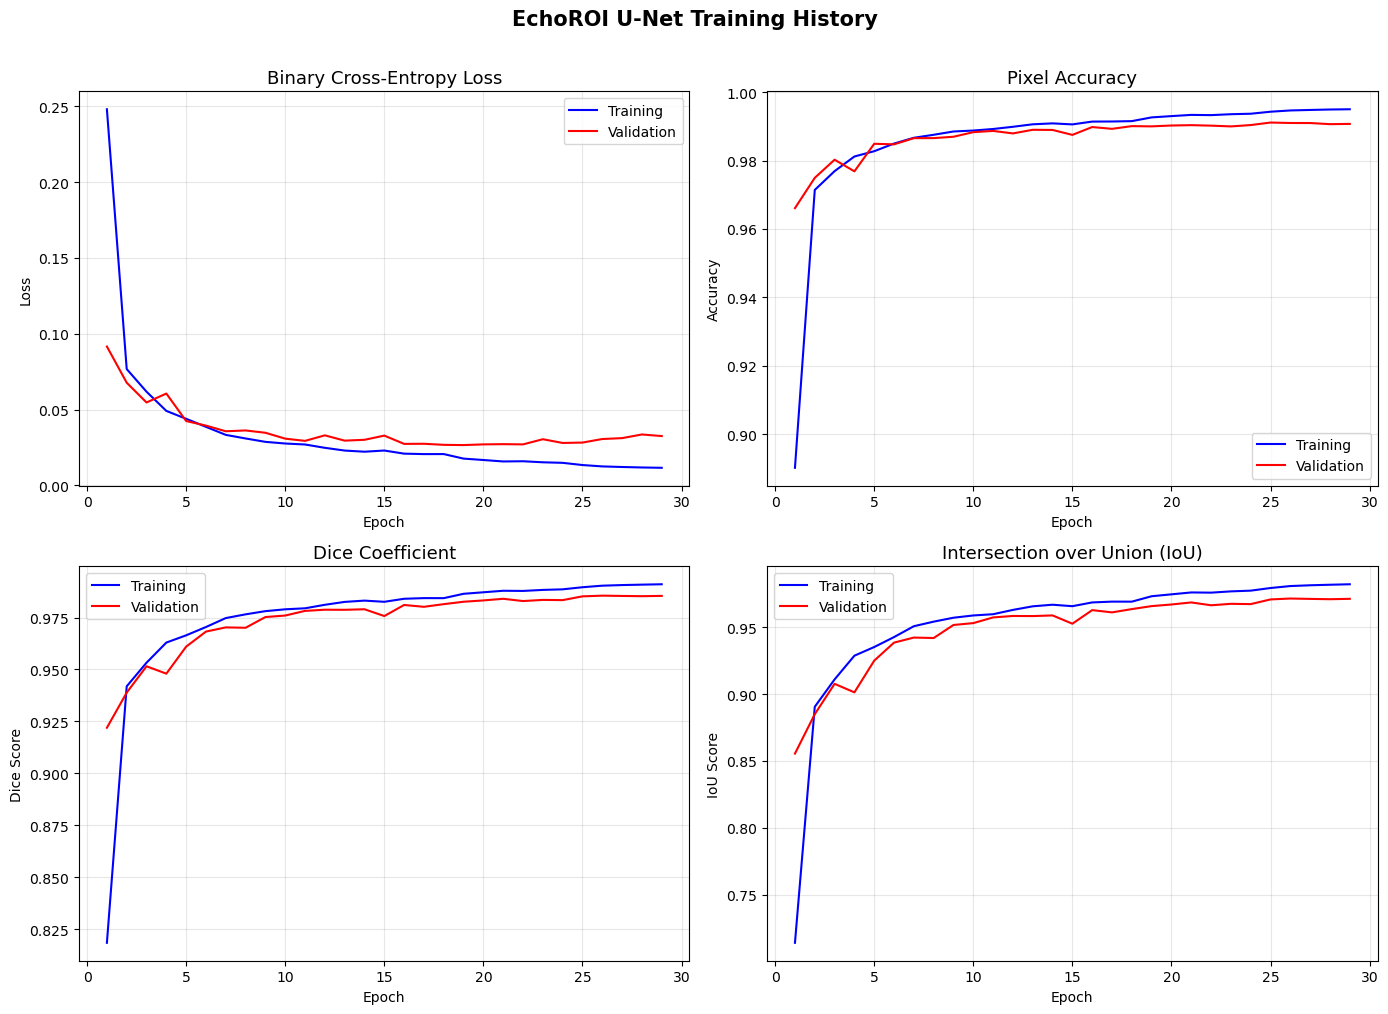

Saved: training_results/training_history.png


In [2]:
epochs = [int(r['epoch']) + 1 for r in log]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(epochs, [float(r['loss']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[0, 0].plot(epochs, [float(r['val_loss']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[0, 0].set_title('Binary Cross-Entropy Loss', fontsize=13)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, [float(r['accuracy']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[0, 1].plot(epochs, [float(r['val_accuracy']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[0, 1].set_title('Pixel Accuracy', fontsize=13)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Dice Coefficient
axes[1, 0].plot(epochs, [float(r['_dice_coefficient']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[1, 0].plot(epochs, [float(r['val__dice_coefficient']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[1, 0].set_title('Dice Coefficient', fontsize=13)
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Dice Score')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# IoU
axes[1, 1].plot(epochs, [float(r['_iou_score']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[1, 1].plot(epochs, [float(r['val__iou_score']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[1, 1].set_title('Intersection over Union (IoU)', fontsize=13)
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('IoU Score')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('EchoROI U-Net Training History', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_results/training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_results/training_history.png")

## 3. Load Trained Model

In [3]:
import tensorflow as tf
from echoroi.preprocessing import UltrasoundPreprocessor
from echoroi.training import calculate_metrics

# Load the trained model
model_path = "models/echoroi_unified.keras"
model = tf.keras.models.load_model(model_path, compile=False)

print(f"Model loaded from: {model_path}")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Parameters:   {model.count_params():,}")
print(f"File size:    {os.path.getsize(model_path) / 1e6:.1f} MB")

Model loaded from: models/echoroi_unified.keras
Input shape:  (None, 256, 256, 1)
Output shape: (None, 256, 256, 1)
Parameters:   31,030,593
File size:    372.5 MB


## 4. Evaluate on Validation Data

Reload the full dataset, apply the same 80/20 split, and evaluate the best model on the held-out validation set.

In [4]:
from sklearn.model_selection import train_test_split

# Load dataset
preprocessor = UltrasoundPreprocessor((256, 256))
X, Y = preprocessor.load_dataset("data/images", "data/masks")

# Same split as training (random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"Validation set: {X_val.shape[0]} samples")

# Predict
Y_pred = model.predict(X_val, verbose=1)

# Calculate metrics
val_metrics = calculate_metrics(Y_val, Y_pred)
print("\nValidation Metrics:")
print("-" * 40)
for k, v in val_metrics.items():
    if k not in ('intersection', 'union'):
        print(f"  {k:20s}: {v:.4f}")

Loaded 1206 samples → Images (1206, 256, 256, 1), Masks (1206, 256, 256, 1)
Validation set: 242 samples
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 725ms/step

Validation Metrics:
----------------------------------------
  dice                : 0.9872
  iou                 : 0.9747
  accuracy            : 0.9900
  sensitivity         : 0.9857
  specificity         : 0.9928


## 5. Prediction Visualization

Display sample predictions comparing input images, ground truth masks, and model predictions.

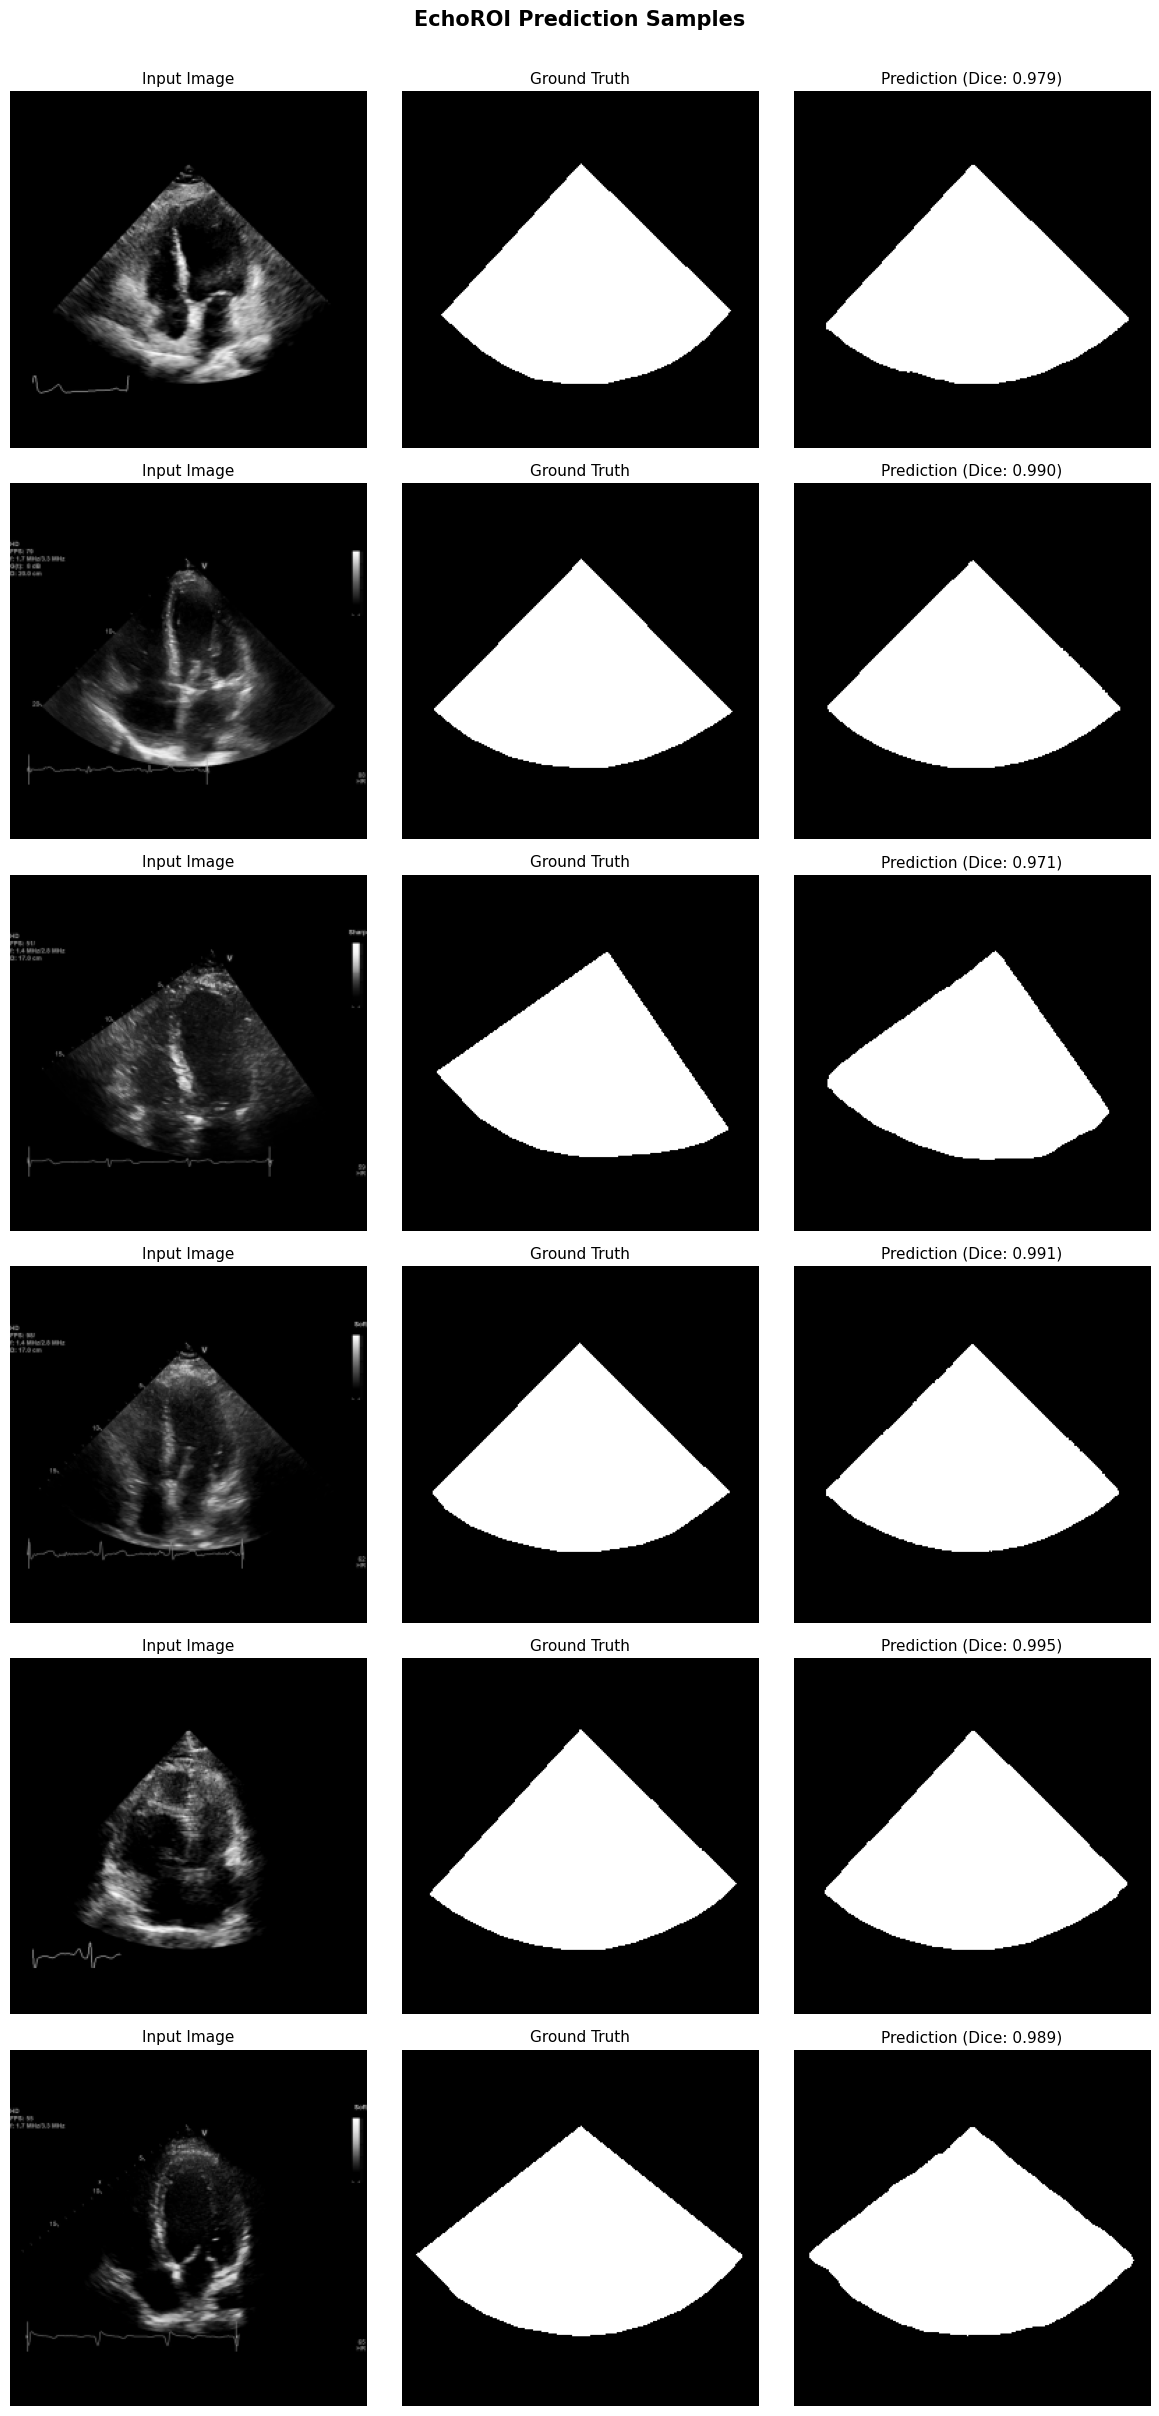

Saved: training_results/prediction_samples.png


In [5]:
n_samples = 6
np.random.seed(42)
indices = np.random.choice(X_val.shape[0], n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))

for i, idx in enumerate(indices):
    img = X_val[idx].squeeze()
    gt = Y_val[idx].squeeze()
    pred = (Y_pred[idx].squeeze() > 0.5).astype(np.float32)
    sample_dice = calculate_metrics(Y_val[idx:idx+1], Y_pred[idx:idx+1])['dice']

    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title('Input Image', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt, cmap='gray')
    axes[i, 1].set_title('Ground Truth', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred, cmap='gray')
    axes[i, 2].set_title(f'Prediction (Dice: {sample_dice:.3f})', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle('EchoROI Prediction Samples', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('training_results/prediction_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_results/prediction_samples.png")

## 6. Per-Sample Dice Distribution

Compute Dice score for each validation sample individually to assess consistency.

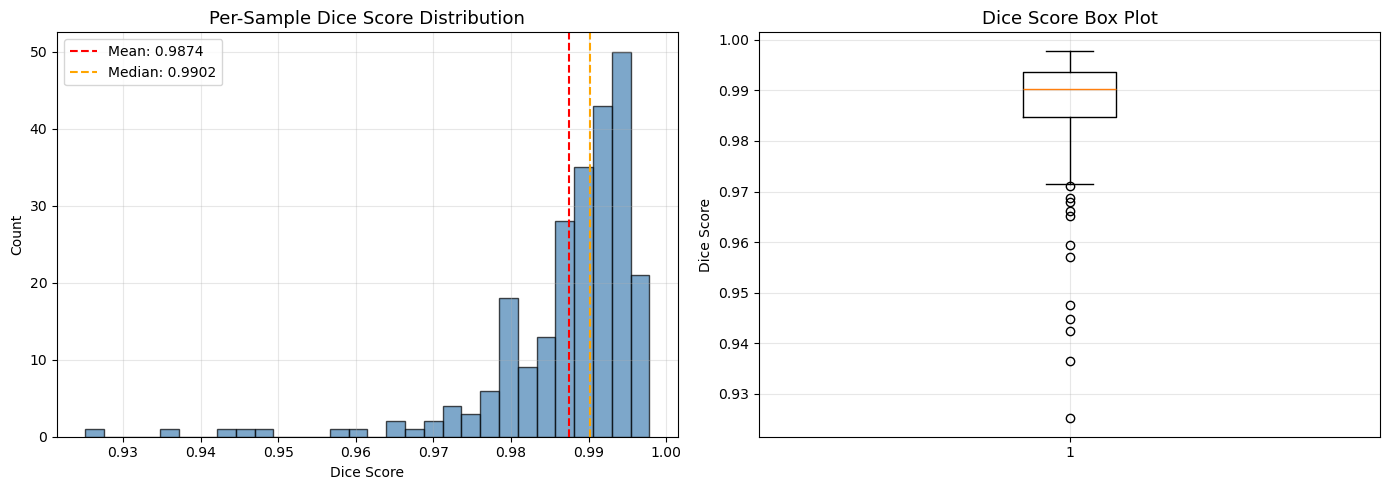


Per-Sample Dice Statistics:
  Mean:   0.9874
  Median: 0.9902
  Std:    0.0100
  Min:    0.9251
  Max:    0.9978
  >0.95:  237 / 242 (97.9%)


In [6]:
# Per-sample Dice scores
per_sample_dice = []
for i in range(X_val.shape[0]):
    m = calculate_metrics(Y_val[i:i+1], Y_pred[i:i+1])
    per_sample_dice.append(m['dice'])

per_sample_dice = np.array(per_sample_dice)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(per_sample_dice, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(per_sample_dice), color='red', linestyle='--',
                label=f'Mean: {np.mean(per_sample_dice):.4f}')
axes[0].axvline(np.median(per_sample_dice), color='orange', linestyle='--',
                label=f'Median: {np.median(per_sample_dice):.4f}')
axes[0].set_title('Per-Sample Dice Score Distribution', fontsize=13)
axes[0].set_xlabel('Dice Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(per_sample_dice, vert=True)
axes[1].set_title('Dice Score Box Plot', fontsize=13)
axes[1].set_ylabel('Dice Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPer-Sample Dice Statistics:")
print(f"  Mean:   {np.mean(per_sample_dice):.4f}")
print(f"  Median: {np.median(per_sample_dice):.4f}")
print(f"  Std:    {np.std(per_sample_dice):.4f}")
print(f"  Min:    {np.min(per_sample_dice):.4f}")
print(f"  Max:    {np.max(per_sample_dice):.4f}")
print(f"  >0.95:  {np.sum(per_sample_dice > 0.95)} / {len(per_sample_dice)}"
      f" ({100*np.mean(per_sample_dice > 0.95):.1f}%)")

## Summary

| Metric | Value |
|---|---|
| **Dice Coefficient** | 0.9872 |
| **IoU (Jaccard)** | 0.9747 |
| **Pixel Accuracy** | 99.0% |
| **Sensitivity** | 98.6% |
| **Specificity** | 99.3% |

The unified EchoROI model achieves strong segmentation performance across all three
datasets with minimal overfitting (29 epochs, early-stopped from 50 configured).

The model and all training artifacts are saved in:
- `models/echoroi_unified.keras` — Trained Keras model
- `models/echoroi_unified.onnx` — ONNX export (see notebook 02)
- `training_results/` — Metrics, plots, and training log